In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [99]:
# #Import dataset
df = pd.read_csv("data.csv", sep=";")
df = df[0:250]

In [100]:
#To print first few instances
print(df.head())

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

In [101]:
#To print column names (attributes/features)
print(df.columns)

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [102]:
#To identify name of target attribute
target_column = df.columns[-1]
print(target_column)

Target


In [103]:
#Checking unique values in the target variable column
unique_targets = df['Target'].unique()
print(unique_targets)

['Dropout' 'Graduate' 'Enrolled']


In [104]:
#Creating a map of labels
label_mapping = {
    'Dropout' : 0,
    'Enrolled' : 1,
    'Graduate' : 2
}

#Replacing target with numeric values
df['Target'] = df['Target'].replace(label_mapping)
df.Target 
#Output: SN Target

C:\Users\Pradeepti\AppData\Local\Temp\ipykernel_26428\4200889998.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target'] = df['Target'].replace(label_mapping)


0      0
1      2
2      0
3      2
4      2
      ..
245    2
246    2
247    0
248    2
249    2
Name: Target, Length: 250, dtype: int64

In [105]:
#To extract target variable
y = df['Target']

#Dropping 'Target' column from the original dataframe df
x = df.drop('Target', axis=1)

print(x.columns) #Target removed

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [106]:
print(x.columns[-1])
print(x.columns[1])

GDP
Application mode


In [107]:
#Representing dataframe 'x' into NumPy array where each row represents a data point and each column represents a feature
matrix = x.values
print(matrix)


[[ 1.   17.    5.   ... 10.8   1.4   1.74]
 [ 1.   15.    1.   ... 13.9  -0.3   0.79]
 [ 1.    1.    5.   ... 10.8   1.4   1.74]
 ...
 [ 1.   44.    1.   ... 13.9  -0.3   0.79]
 [ 1.    1.    3.   ... 11.1   0.6   2.02]
 [ 1.    1.    1.   ... 11.1   0.6   2.02]]


In [108]:
#To find out information about rows and columns
dimension = matrix.shape
print(dimension)
#output = (instances, features)

(250, 36)


In [109]:
#Generate pairplor using Seaborn's 'pairplot' function
# import seaborn as sns
# p = sns.pairplot(df, hue='Target')

In [110]:
#FOr initial plot
corr_matrix = df.corr()
corr = corr_matrix['Target']
print(corr)


Marital status                                    0.032803
Application mode                                 -0.193015
Application order                                 0.009457
Course                                            0.070422
Daytime/evening attendance\t                      0.020960
Previous qualification                           -0.074496
Previous qualification (grade)                    0.151041
Nacionality                                       0.013559
Mother's qualification                            0.096138
Father's qualification                            0.064320
Mother's occupation                               0.057478
Father's occupation                               0.066600
Admission grade                                   0.147126
Displaced                                         0.001178
Educational special needs                         0.095948
Debtor                                           -0.224234
Tuition fees up to date                           0.3084

In [111]:
#Mean for each dimension
attribute_means = np.mean(matrix, axis=0) 
#along the rows (attribuutes)
print(attribute_means)

[1.08800000e+00 1.68520000e+01 1.86400000e+00 8.94038000e+03
 9.08000000e-01 3.88000000e+00 1.32117200e+02 1.68400000e+00
 1.82240000e+01 2.17960000e+01 8.32400000e+00 8.57600000e+00
 1.26198400e+02 5.84000000e-01 1.20000000e-02 9.60000000e-02
 9.16000000e-01 1.56000000e-01 2.72000000e-01 2.20800000e+01
 2.00000000e-02 4.16000000e-01 6.04400000e+00 7.94000000e+00
 4.67600000e+00 1.06881303e+01 6.00000000e-02 3.00000000e-01
 6.11200000e+00 7.74800000e+00 4.40400000e+00 1.03157758e+01
 1.20000000e-01 1.16124000e+01 1.11880000e+00 1.68400000e-02]


In [112]:
print(attribute_means.shape)
print(df.columns[-1])

(36,)
Target


In [113]:
#Subtract mean from each dimension
standardized_data = matrix - attribute_means
print(standardized_data)

[[ -0.088     0.148     3.136   ...  -0.8124    0.2812    1.72316]
 [ -0.088    -1.852    -0.864   ...   2.2876   -1.4188    0.77316]
 [ -0.088   -15.852     3.136   ...  -0.8124    0.2812    1.72316]
 ...
 [ -0.088    27.148    -0.864   ...   2.2876   -1.4188    0.77316]
 [ -0.088   -15.852     1.136   ...  -0.5124   -0.5188    2.00316]
 [ -0.088   -15.852    -0.864   ...  -0.5124   -0.5188    2.00316]]


In [114]:
#Creating new standardized dataframe
#Output of data standardization block
df_standardized = pd.DataFrame(standardized_data)
df_standardized

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,-0.088,0.148,3.136,-8769.38,0.092,-2.88,-10.1172,-0.684,0.776,-9.796,...,-0.06,-0.3,-6.112,-7.748,-4.404,-10.315776,-0.12,-0.8124,0.2812,1.72316
1,-0.088,-1.852,-0.864,313.62,0.092,-2.88,27.8828,-0.684,-17.224,-18.796,...,-0.06,-0.3,-0.112,-1.748,1.596,3.350891,-0.12,2.2876,-1.4188,0.77316
2,-0.088,-15.852,3.136,129.62,0.092,-2.88,-10.1172,-0.684,18.776,15.204,...,-0.06,-0.3,-0.112,-7.748,-4.404,-10.315776,-0.12,-0.8124,0.2812,1.72316
3,-0.088,0.148,0.136,832.62,0.092,-2.88,-10.1172,-0.684,19.776,15.204,...,-0.06,-0.3,-0.112,2.252,0.596,2.084224,-0.12,-2.2124,-1.9188,-3.13684
4,0.912,22.148,-0.864,-926.38,-0.908,-2.88,-32.1172,-0.684,18.776,16.204,...,-0.06,-0.3,-0.112,-1.748,1.596,2.684224,-0.12,2.2876,-1.4188,0.77316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,-0.088,-9.852,-0.864,559.62,0.092,-0.88,-2.1172,-0.684,0.776,16.204,...,-0.06,-0.3,1.888,0.252,3.596,2.904224,-0.12,-2.2124,-1.9188,-3.13684
246,-0.088,0.148,1.136,559.62,0.092,-2.88,-3.1172,-0.684,0.776,15.204,...,-0.06,-0.3,1.888,0.252,2.596,2.835653,-0.12,-0.8124,0.2812,1.72316
247,-0.088,27.148,-0.864,62.62,0.092,35.12,-2.1172,-0.684,18.776,15.204,...,-0.06,-0.3,-0.112,0.252,-1.404,1.017558,-0.12,2.2876,-1.4188,0.77316
248,-0.088,-15.852,1.136,313.62,0.092,-2.88,-11.1172,-0.684,0.776,15.204,...,-0.06,-0.3,-0.112,0.252,-0.404,1.934224,-0.12,-0.5124,-0.5188,2.00316


In [115]:
#Vairance
variance = df_standardized.var()
print(variance)

0     1.608996e-01
1     2.883836e+02
2     1.925205e+00
3     3.728669e+06
4     8.387149e-02
5     9.057189e+01
6     1.323229e+02
7     2.993589e+01
8     2.230420e+02
9     2.302996e+02
10    3.029990e+02
11    2.807111e+02
12    1.986462e+02
13    2.439197e-01
14    1.190361e-02
15    8.713253e-02
16    7.725301e-02
17    1.321928e-01
18    1.988112e-01
19    4.120643e+01
20    1.967871e-02
21    3.408578e+00
22    4.588418e+00
23    1.328554e+01
24    7.352434e+00
25    2.050736e+01
26    8.875502e-02
27    1.977912e+00
28    3.794635e+00
29    1.338604e+01
30    8.145365e+00
31    2.623963e+01
32    3.871486e-01
33    7.547275e+00
34    1.843139e+00
35    5.023982e+00
dtype: float64


In [116]:
#Covariance matrix of standardized data
covariance_matrix = df_standardized.cov()
print(covariance_matrix) 
#Symmetric

           0            1          2             3         4            5   \
0    0.160900     1.454843  -0.064289  1.991422e+01 -0.032032     0.388112   
1    1.454843   288.383631  -7.578442  1.905346e+03 -1.491582    69.054458   
2   -0.064289    -7.578442   1.925205 -9.921317e+01  0.079807    -2.498313   
3   19.914217  1905.345622 -99.213173  3.728669e+06 -1.768112  1011.338956   
4   -0.032032    -1.491582   0.079807 -1.768112e+00  0.083871    -0.440803   
5    0.388112    69.054458  -2.498313  1.011339e+03 -0.440803    90.571888   
6    0.021372   -12.171741  -2.187611  5.944284e+01  0.125284     1.894442   
7   -0.060434    -3.797960   0.057253  2.588676e+02  0.063181    -1.214779   
8    0.442056     7.888707   0.187213  2.287862e+03 -0.537542     4.316145   
9    0.214811   -18.190956   0.100659  5.840497e+02 -0.287920   -13.241446   
10  -0.145092    10.987904  -1.116402  1.342238e+03  0.130329    -7.238072   
11  -0.279807     0.708080  -1.001671  6.315473e+02  0.209831   

In [117]:
#Eigenvectors and Eigenvalues of covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
print("Eigenvalues: \n", eigenvalues)
print("\nEigenvectors: \n", eigenvectors)

Eigenvalues: 
 [3.72868539e+06 5.76912153e+02 3.37481380e+02 3.15764853e+02
 2.76096557e+02 1.25245076e+02 7.49505162e+01 5.13447401e+01
 4.90867563e+01 3.02321901e+01 2.75201426e+01 1.31668618e+01
 1.07022487e+01 8.55356316e+00 7.96581138e+00 4.13631376e+00
 3.49026734e+00 2.35300166e+00 1.79506369e+00 1.58727140e+00
 1.02825269e+00 9.41818942e-01 5.34969074e-01 3.21657324e-01
 2.19811796e-01 4.01781255e-03 1.06383588e-02 1.63466626e-01
 1.54358928e-01 3.39058044e-02 5.56390973e-02 6.61357865e-02
 1.09241698e-01 1.03536234e-01 9.73249355e-02 8.39367342e-02]

Eigenvectors: 
 [[-5.34112629e-06  3.98948613e-04 -2.40034893e-03 ...  7.12076496e-01
  -5.73775936e-01  4.08947248e-02]
 [-5.11035929e-04 -2.23308737e-02 -6.11651358e-01 ... -2.41157758e-04
  -2.17652026e-03 -1.38092848e-03]
 [ 2.66097204e-05  3.32963092e-03  1.59205771e-02 ... -4.07972605e-03
  -1.75314609e-02  2.86698058e-03]
 ...
 [-3.33468221e-05  1.30684009e-02 -1.65747971e-02 ...  2.93787121e-03
  -4.79455347e-03  3.5441293

In [118]:
#Sort data by Eigenvalue in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("Sorted Eigenvalues: \n", sorted_eigenvalues)
print("\nSorted eigenvectors: \n", sorted_eigenvectors)

Sorted Eigenvalues: 
 [3.72868539e+06 5.76912153e+02 3.37481380e+02 3.15764853e+02
 2.76096557e+02 1.25245076e+02 7.49505162e+01 5.13447401e+01
 4.90867563e+01 3.02321901e+01 2.75201426e+01 1.31668618e+01
 1.07022487e+01 8.55356316e+00 7.96581138e+00 4.13631376e+00
 3.49026734e+00 2.35300166e+00 1.79506369e+00 1.58727140e+00
 1.02825269e+00 9.41818942e-01 5.34969074e-01 3.21657324e-01
 2.19811796e-01 1.63466626e-01 1.54358928e-01 1.09241698e-01
 1.03536234e-01 9.73249355e-02 8.39367342e-02 6.61357865e-02
 5.56390973e-02 3.39058044e-02 1.06383588e-02 4.01781255e-03]

Sorted eigenvectors: 
 [[-5.34112629e-06  3.98948613e-04 -2.40034893e-03 ...  4.62985720e-02
   5.06973501e-02 -2.17125332e-03]
 [-5.11035929e-04 -2.23308737e-02 -6.11651358e-01 ...  9.33150155e-04
   1.61534695e-04 -3.38424777e-05]
 [ 2.66097204e-05  3.32963092e-03  1.59205771e-02 ...  1.08330303e-02
   1.80756522e-02  3.34649865e-03]
 ...
 [-3.33468221e-05  1.30684009e-02 -1.65747971e-02 ... -3.69476743e-03
   1.78552880e

In [119]:
#Derive new data
transformed_data = np.dot(standardized_data, sorted_eigenvectors)
print(transformed_data)

[[ 8.76940312e+03 -1.59405972e+00 -5.47497088e+00 ...  6.54202632e-02
   2.95454859e-02 -6.87618759e-04]
 [-3.13610764e+02  4.85167356e+00 -1.38892292e+01 ...  7.17283664e-01
  -5.14678477e-02 -2.76456185e-02]
 [-1.29590578e+02  3.42437153e-01  2.65879387e+01 ...  6.57469367e-01
   5.68043694e-02 -1.55193189e-02]
 ...
 [-6.26630230e+01 -1.94579664e+00 -7.14886571e+00 ...  1.26942894e-02
  -7.81796942e-03 -1.03069388e-01]
 [-3.13612107e+02  6.46819163e+00  1.85805163e+01 ... -4.63563344e-02
   5.44463224e-03  6.71178465e-03]
 [-7.29617659e+02 -4.28051667e-01 -4.92678608e-01 ... -1.22390816e-02
  -8.79295138e-03 -1.52443548e-03]]


In [120]:
#Creating new dataframe of transformed data
df_transformed = pd.DataFrame(transformed_data)
print(df_transformed)

              0         1          2          3          4          5   \
0    8769.403124 -1.594060  -5.474971  -2.106986   3.616664   9.120018   
1    -313.610764  4.851674 -13.889229  19.581168 -30.282554   0.392374   
2    -129.590578  0.342437  26.587939  -4.552712   9.402540   3.917071   
3    -832.635450  7.339726  17.947549 -15.211523  11.646843   4.013797   
4     926.346506 -1.370239  -0.532478 -34.549426   6.172882  -0.994477   
..           ...       ...        ...        ...        ...        ...   
245  -559.625464  7.055862  15.875050   0.180743  -2.039527  -8.993816   
246  -559.627761  4.049946   9.907877  -5.394233   7.174836  -9.485937   
247   -62.663023 -1.945797  -7.148866 -42.853049  -5.778444   1.914595   
248  -313.612107  6.468192  18.580516   5.229644  14.372861  -7.446374   
249  -729.617659 -0.428052  -0.492679  21.216541  -0.274965  16.632739   

            6          7          8          9   ...        26        27  \
0    -1.759698   9.348897   4.77379

In [121]:
#Computing sum of all eigenvalues
eigenvalue_sum = np.sum(sorted_eigenvalues)

#Proportion variance
proporion_variance = sorted_eigenvalues / eigenvalue_sum
print(proporion_variance)
sum(proporion_variance)

[9.99484718e-01 1.54642943e-04 9.04628434e-05 8.46416666e-05
 7.40084671e-05 3.35722986e-05 2.00906990e-05 1.37631036e-05
 1.31578446e-05 8.10382450e-06 7.37685245e-06 3.52941474e-06
 2.86876820e-06 2.29280692e-06 2.13525839e-06 1.10875066e-06
 9.35576083e-07 6.30728784e-07 4.81171924e-07 4.25472611e-07
 2.75626058e-07 2.52457245e-07 1.43399981e-07 8.62211602e-08
 5.89211769e-08 4.38176940e-08 4.13763496e-08 2.92825477e-08
 2.77531818e-08 2.60882256e-08 2.24994802e-08 1.77278856e-08
 1.49142182e-08 9.08854726e-09 2.85164232e-09 1.07698608e-09]


1.0000000000000002

In [122]:
#Project dataset onto selected eigenvectors
principal_components = np.dot(transformed_data, sorted_eigenvectors)

no_of_attr = principal_components.shape[1] #count columns
print(no_of_attr)

36


In [123]:
#Covariance matrix of standardized data
cov_pca = np.cov(principal_components, rowvar=False)
pca_df = pd.DataFrame(cov_pca)
print(pca_df) 

            0            1            2             3            4   \
0   315.763762    -0.130325     0.240388      0.109964    -0.049930   
1    -0.130325    21.657027     3.270621      1.445648    -1.740816   
2     0.240388     3.270621   264.191120    277.582495    16.626734   
3     0.109964     1.445648   277.582495    402.341985    37.776134   
4    -0.049930    -1.740816    16.626734     37.776134    44.468255   
5     0.130302     0.143168    47.674100     41.500439    -0.084145   
6    -0.283202    -2.715979   -64.099304    -93.336876   -17.059265   
7    -0.488495     8.861698    -9.872729    -49.749247   -11.869663   
8     0.164057     5.948878   -85.130071   -139.951527    -4.297102   
9    -0.570915    53.176454  -246.875749   -590.429528  -218.017135   
10    0.233006   -19.173331    77.673102    202.796215    86.166139   
11    0.008870    -2.463714   -30.626943    -31.175327     2.498644   
12    0.183621   -17.786496    72.902473    151.216909    47.530915   
13   -

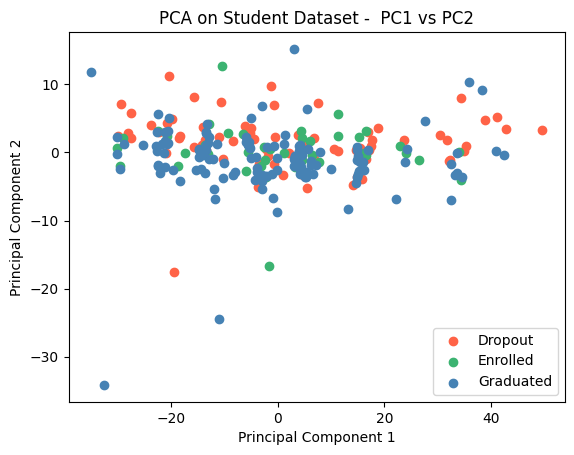

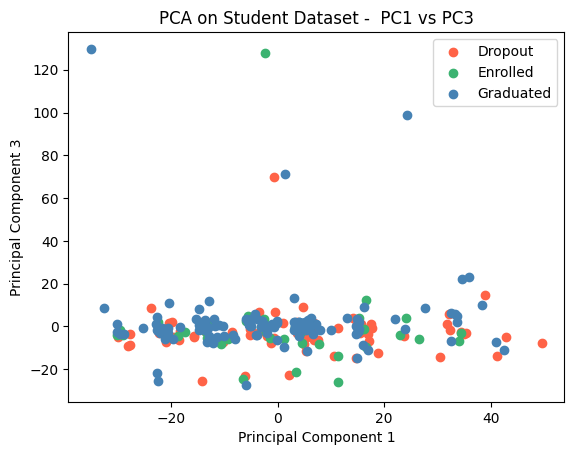

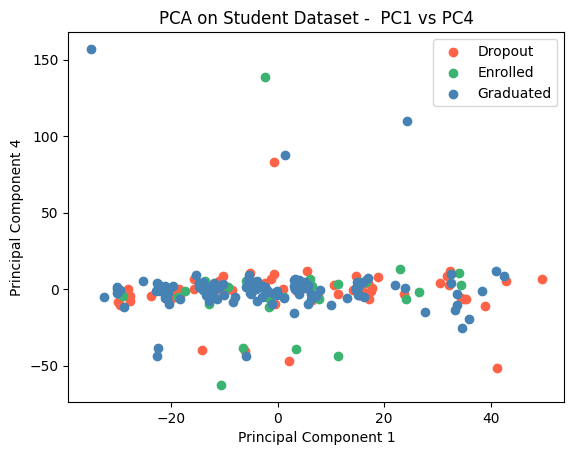

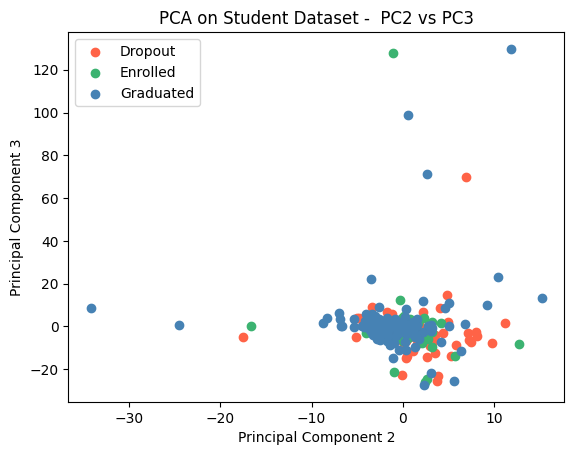

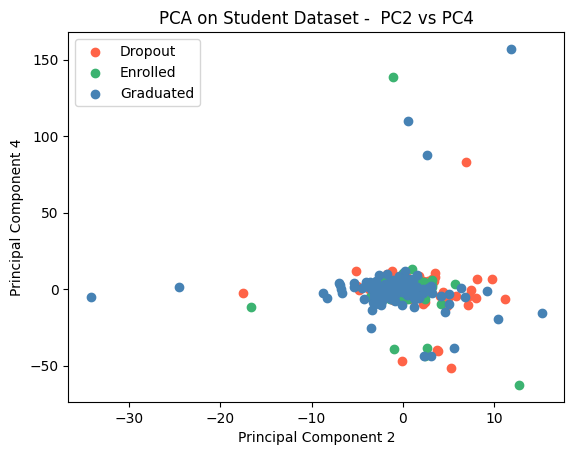

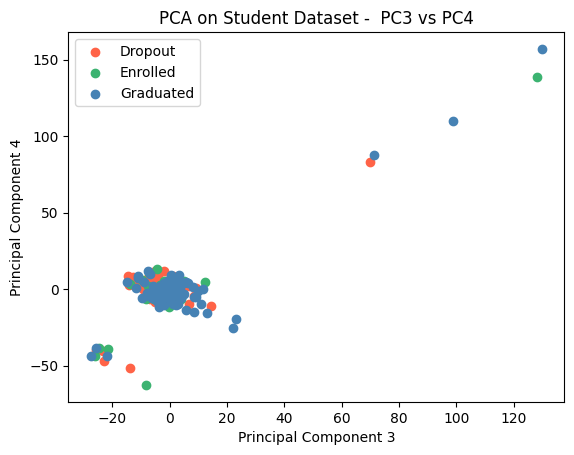

In [124]:
#Defining markers
# markers = ['x', '+', '.']
colours = ['#FF6347', '#3CB371', '#4682b4']
target_labels = ['Dropout', 'Enrolled', 'Graduated']
abc = 4

#2D plot
for i in range (abc - 1): #35
    for j in range (i+1, abc): #i+1 to 35
        fig = plt.figure()
        for k in range (len(np.unique(y))): #3?
            plt.scatter(principal_components[y==k, i], principal_components[y==k, j], color=colours[k])
            plt.xlabel('Principal Component {}'.format(i+1))
            plt.ylabel('Principal Component {}'.format(j+1))
            plt.legend(target_labels)
            plt.title('PCA on Student Dataset -  PC{} vs PC{}'.format(i+1, j+1))
            
            plt.savefig('PC{} vs PC{}'.format(i+1, j+1))

In [125]:
#To plot data values
from sklearn.decomposition import PCA

#define PCA model to use
pca = PCA(n_components=4)

#fit PCA model to data
pca_fit = pca.fit(x)
print(pca.explained_variance_ratio_)

[9.99484718e-01 1.54642943e-04 9.04628434e-05 8.46416666e-05]


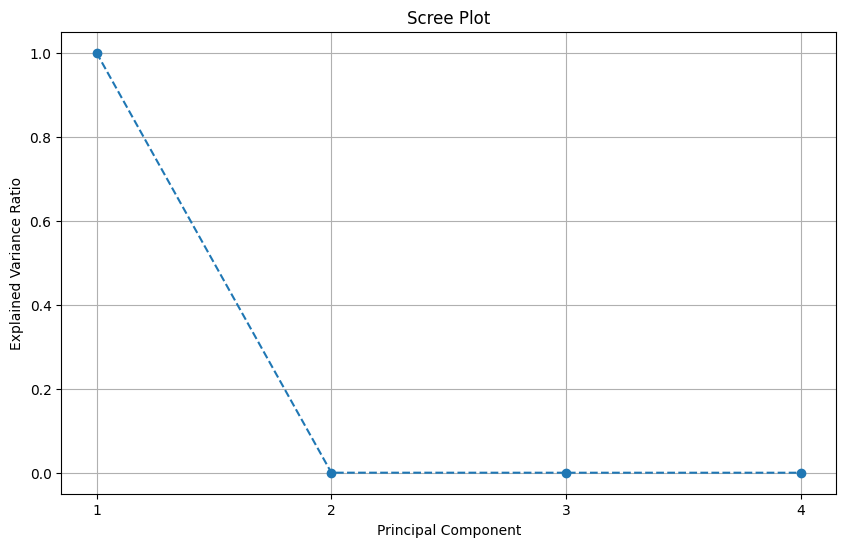

<Figure size 640x480 with 0 Axes>

In [126]:
#Final scree plot
explained_variance_ratio = pca.explained_variance_ratio_

# Plotting the scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid()
plt.show()
plt.savefig('screeplot')

In [127]:
# # Create the scree plot
# plt.figure(figsize=(8, 6))  # Adjust figure size as needed
# plt.plot(range(1, len(sorted_eigenvalues) + 1), sorted_eigenvalues, marker='o', linestyle='-')
# plt.xlabel('Principal Component')
# plt.ylabel('Eigenvalue')  # You can change this to 'Explained Variance Ratio' if using the calculated ratio
# plt.title('Scree Plot')
# plt.grid(True)
# plt.show()

In [128]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.decomposition import PCA

# # Load your custom dataset
# file_path = 'data.csv'  # Replace with your dataset file path
# df = pd.read_csv(file_path, sep=';')

# # Assuming the target column is labeled as 'target', if present
# #If your dataset has a target column, you may want to drop it for PCA
# X = df.drop(columns='Target')

# # If there's no target column, use the whole dataframe for PCA
# X = df.select_dtypes(include=[np.number])  # Select only numerical columns for PCA

# # Perform PCA
# pca = PCA()
# principal_components = pca.fit_transform(X)

# # Explained variance ratio
# explained_variance_ratio = pca.explained_variance_ratio_

# # Scree plot
# plt.figure()
# plt.plot(np.arange(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'o-', markersize=8)
# plt.xlabel('Principal Component')
# plt.ylabel('Explained Variance Ratio')
# plt.title('Scree Plot of Custom Dataset')
# plt.xticks(np.arange(1, len(explained_variance_ratio) + 1))
# plt.grid()
# plt.show()


In [129]:
# Check unique values in the target variable
X = df.drop(columns='Target')  # Replace 'target' with the name of your target column
y = df['Target']  # Replace 'target' with the name of your target column
print("Unique values in target:", np.unique(y))

Unique values in target: [0 1 2]


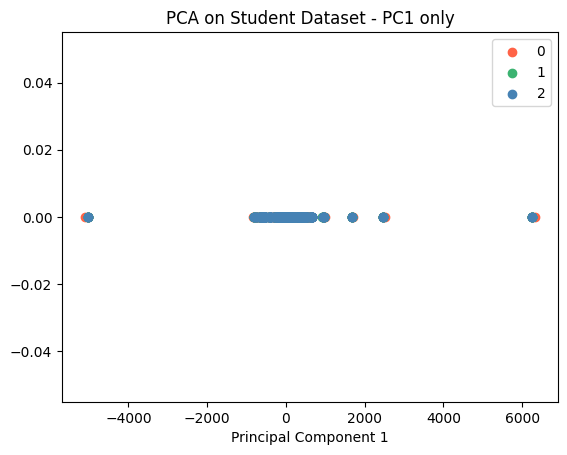

<Figure size 640x480 with 0 Axes>

In [130]:
# Define markers and target labels
# markers = ['x', '+', '.']
colours = ['#FF6347', '#3CB371', '#4682b4']
target_labels = ['Dropout', 'Enrolled', 'Graduated']

# 1D plot using the first principal component
fig = plt.figure()
for k, target_label in enumerate(np.unique(y)):
    plt.scatter(principal_components[y == target_label], np.zeros_like(principal_components[y == target_label]), color=colours[k], label=target_label)
plt.xlabel('Principal Component 1')
plt.title('PCA on Student Dataset - PC1 only')
plt.legend()
plt.show()
plt.savefig('PC1')


In [131]:
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# # Assuming you already have principal components stored in 'principal_components'
# # principal_components should be a 2D array with shape (n_samples, n_components)

# colours = ['#FF6347', '#3CB371', '#4682b4']
# target_labels = ['Dropout', 'Enrolled', 'Graduated']

# # Plot 3D scatter plot for PC1, PC2, and PC3
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# # Scatter plot for each class
# for target_label in zip(np.unique(y), colours):
#     ax.scatter(principal_components[y == target_label, 0], principal_components[y == target_label, 1], principal_components[y == target_label, 2], label=target_label[target_label], color=colours)

# ax.set_xlabel('PC1')
# ax.set_ylabel('PC2')
# ax.set_zlabel('PC3')
# ax.set_title('3D PCA Plot')
# ax.legend()

# plt.show()



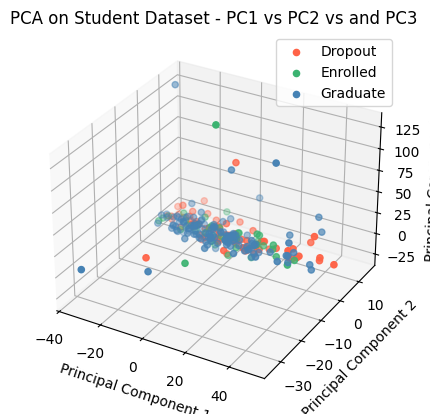

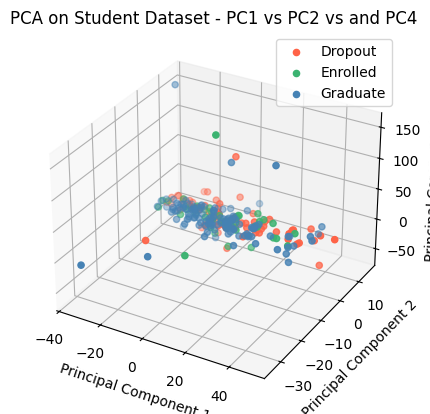

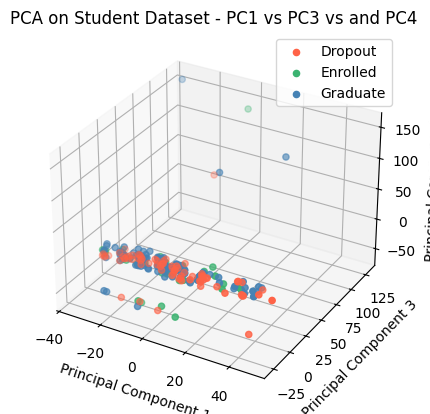

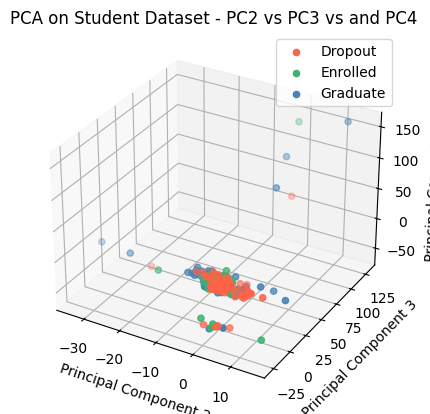

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import itertools
import pandas as pd

# Assuming df is your DataFrame and principal_components is your array of sorted principal components
# and y contains the target labels as integers corresponding to label_mapping

# Create a mapping of target labels to colors
target_labels = ['Dropout', 'Enrolled', 'Graduate']
# colors = ['r', 'g', 'b']  # Red, Green, Blue
colors = ['#FF6347', '#3CB371', '#4682b4']

color_mapping = dict(zip(target_labels, colors))

# Ensure that the target column has integer values representing the labels
# Create a map of labels
label_mapping = {
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
}

# Replace target labels with numeric values
df['Target'] = df['Target'].replace(label_mapping)
y = df['Target'].values

# Extract the first four principal components
pc1 = principal_components[:, 0]
pc2 = principal_components[:, 1]
pc3 = principal_components[:, 2]
pc4 = principal_components[:, 3]

# Create a list of the first four principal components
pcs = [pc1, pc2, pc3, pc4]

# Generate all combinations of 3 principal components from the first four
combinations = list(itertools.combinations(range(4), 3))

# Create 3D plots for each combination
figures = []

for comb in combinations:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the points using the combination of principal components
    for target_label, color in color_mapping.items():
        indices = (y == label_mapping[target_label])
        ax.scatter(pcs[comb[0]][indices], pcs[comb[1]][indices], pcs[comb[2]][indices], 
                   c=color, label=target_label)
    
    ax.set_xlabel(f'Principal Component {comb[0] + 1}')
    ax.set_ylabel(f'Principal Component {comb[1] + 1}')
    ax.set_zlabel(f'Principal Component {comb[2] + 1}')
    ax.set_title(f'PCA on Student Dataset - PC{comb[0] + 1} vs PC{comb[1] + 1} vs and PC{comb[2] + 1}')
    ax.legend()
    filename = f'PC{comb[0] + 1}_PC{comb[1] + 1}_PC{comb[2] + 1}.png'
    plt.savefig(filename)
    
    figures.append(fig)

# Display the plots
plt.show()

# # Optionally, save the figures as images
# for i, fig in enumerate(figures):
#     fig.savefig(f'PC{comb[0] + 1}, {comb[1] + 1} and {comb[1] + 1}')
